<a href="https://colab.research.google.com/github/sahilshirsat2004-coder/CSL701-CE45_Machine-Learning-Lab/blob/main/copy_of_ml_experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

Name: Sahil Ganesh Shirsat     

Roll no :CE45

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# For displaying tables
from IPython.display import display

print("NumPy version:", np.__version__)
print("Environment setup completed.")

NumPy version: 2.0.2
Environment setup completed.


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [3]:
from google.colab import files
import io
import pandas as pd
import numpy as np # numpy is used later in the cell for df.select_dtypes

# Upload the dataset file
print("Please upload 'cardekho_dataset.csv' when prompted:")
uploaded = files.upload()

# Load dataset from uploaded files
if 'cardekho_dataset.csv' in uploaded:
    df = pd.read_csv(io.BytesIO(uploaded['cardekho_dataset.csv']))
else:
    raise FileNotFoundError("Error: 'cardekho_dataset.csv' was not found in the uploaded files. Please ensure you upload the correct file.")

# Display first 5 records
display(df.head())

# Number of rows and columns
print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Numerical and categorical attributes
print("\nNumerical attributes:")
print(df.select_dtypes(include=np.number).columns.tolist())
print("\nCategorical attributes:")
print(df.select_dtypes(exclude=np.number).columns.tolist())

# Target variable
print("\nTarget variable: Selling_Price")

Please upload 'cardekho_dataset.csv' when prompted:


Saving cardekho_dataset.csv to cardekho_dataset.csv


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows: 15411
Number of columns: 14

Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target variable: Selling_Price


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [7]:
print("Missing values in each column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

# Handle missing values
# If missing values exist, remove incomplete rows
if df.isnull().sum().sum() > 0:
    df = df.dropna().reset_index(drop=True)
    print("\nRows containing missing values were removed.")
else:
    print("\nNo missing values found. No rows were removed.")

# Verify
print("\nMissing values after preprocessing:")
print(df.isnull().sum())
print("\nFinal dataset shape:", df.shape)

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
Car_Age              0
dtype: int64

Total missing values: 0

No missing values found. No rows were removed.

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
Car_Age              0
dtype: int64

Final dataset shape: (15411, 15)


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [8]:
CURRENT_YEAR = 2026
df["Car_Age"] = df["vehicle_age"]

# Selected features
features = [
    "max_power",          # Replaced 'Present_Price' with 'max_power'
    "km_driven",          # Corrected 'Kms_Driven'
    "fuel_type",          # Corrected 'Fuel_Type'
    "seller_type",        # Corrected 'Seller_Type'
    "transmission_type",  # Corrected 'Transmission'
    "Car_Age"
]
target = "selling_price"  # Corrected 'Selling_Price' to 'selling_price'

X = df[features].copy()
y = df[target].copy()

print("Selected predictor variables:")
print(features)
print("\nTarget variable:")
print(target)

display(X.head())
display(y.head())

Selected predictor variables:
['max_power', 'km_driven', 'fuel_type', 'seller_type', 'transmission_type', 'Car_Age']

Target variable:
selling_price


,max_power,km_driven,fuel_type,seller_type,transmission_type,Car_Age
0,46.30,120000,Petrol,Individual,Manual,9
1,82.00,20000,Petrol,Individual,Manual,5
2,80.00,60000,Petrol,Individual,Manual,11
3,67.10,37000,Petrol,Individual,Manual,9
4,98.59,30000,Diesel,Dealer,Manual,6


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [9]:
categorical_features = [
    "fuel_type",          # Corrected from 'Fuel_Type'
    "seller_type",        # Corrected from 'Seller_Type'
    "transmission_type"   # Corrected from 'Transmission'
]

# One-hot/dummy encoding
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=float
)

print("Dataset after categorical encoding:")
display(X_encoded.head())

print("\nAll predictor columns:")
print(X_encoded.columns.tolist())
print("\nData types:")
print(X_encoded.dtypes)

# Verify that all predictors are numerical
print("\nAre all predictors numerical?",
      all(np.issubdtype(dtype, np.number) for dtype in X_encoded.dtypes))

Dataset after categorical encoding:


,max_power,km_driven,Car_Age,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,46.30,120000,9,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1,82.00,20000,5,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,80.00,60000,11,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,67.10,37000,9,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,98.59,30000,6,1.0,0.0,0.0,0.0,0.0,0.0,1.0



All predictor columns:
['max_power', 'km_driven', 'Car_Age', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual']

Data types:
max_power                       float64
km_driven                         int64
Car_Age                           int64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
transmission_type_Manual        float64
dtype: object

Are all predictors numerical? True


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [10]:
print("Sample vehicle_age and Car_Age values:")
display(
    df[["vehicle_age", "Car_Age"]].head(10)
)

print("\nMinimum car age:", df["Car_Age"].min())
print("Maximum car age:", df["Car_Age"].max())

# The original 'vehicle_age' column was already excluded when creating X,
# and 'Car_Age' was added. There is no 'Year' column to drop.
# X_encoded = X_encoded.drop(columns=["Year"], errors="ignore") # This line is not needed as 'Year' does not exist.

print("\nFinal predictors (X_encoded already contains Car_Age and not vehicle_age):")
print(X_encoded.columns.tolist())

Sample vehicle_age and Car_Age values:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Minimum car age: 0
Maximum car age: 29

Final predictors (X_encoded already contains Car_Age and not vehicle_age):
['max_power', 'km_driven', 'Car_Age', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual']


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

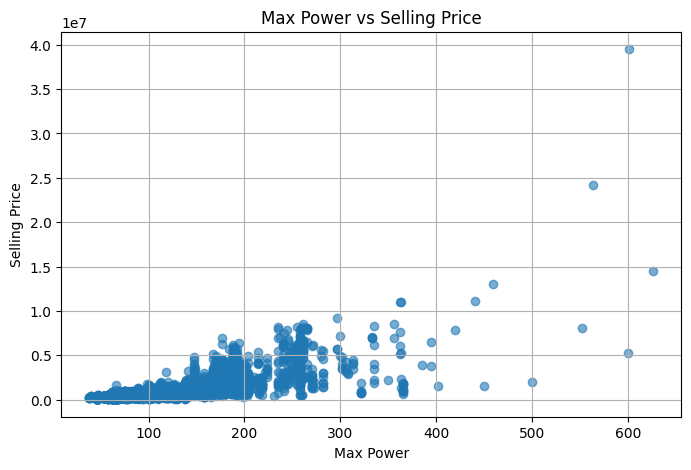

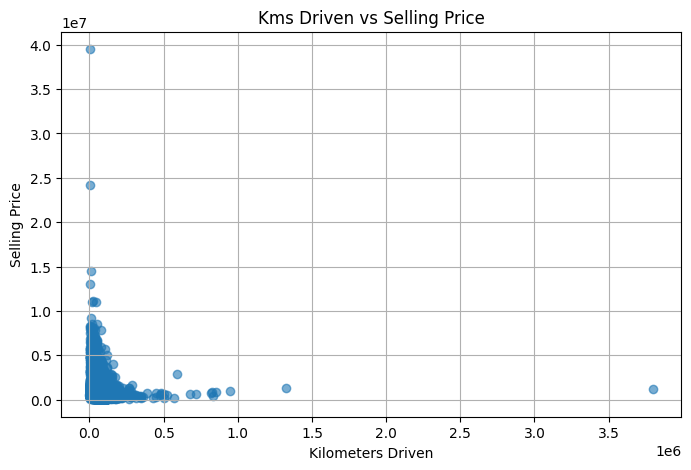

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["max_power"], # Corrected from 'Present_Price'
    df["selling_price"], # Corrected from 'Selling_Price'
    alpha=0.6
)
plt.xlabel("Max Power")
plt.ylabel("Selling Price")
plt.title("Max Power vs Selling Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    df["km_driven"], # Corrected from 'Kms_Driven'
    df["selling_price"], # Corrected from 'Selling_Price'
    alpha=0.6
)
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.title("Kms Driven vs Selling Price")
plt.grid(True)
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [15]:
print("Feature columns before splitting:")
print(X_encoded.columns.tolist())

# Convert DataFrame to NumPy arrays (moved from Task 9)
X_data = X_encoded.to_numpy(dtype=float)
y_data = y.to_numpy(dtype=float)

# Fixed random seed (moved from Task 9)
np.random.seed(42)

# Random permutation (moved from Task 9)
indices = np.random.permutation(len(X_data))

# 80:20 split (moved from Task 9)
train_size = int(0.80 * len(X_data))
train_indices = indices[:train_size]
test_indices = indices[train_size:]

Xtrain = X_data[train_indices]
Xtest = X_data[test_indices]
ytrain = y_data[train_indices]
ytest = y_data[test_indices]

# Calculate mean and standard deviation using TRAINING DATA ONLY
train_mean = np.mean(Xtrain, axis=0)
train_std = np.std(Xtrain, axis=0)

# Avoid division by zero
train_std[train_std == 0] = 1

# Standardize training data
Xtrain_scaled = (Xtrain - train_mean) / train_std

# Standardize test data using training statistics
Xtest_scaled = (Xtest - train_mean) / train_std

print("\nTraining observations:", len(Xtrain))
print("Testing observations:", len(Xtest))
print("\nTraining ratio:", len(Xtrain) / len(X_data))
print("Testing ratio:", len(Xtest) / len(X_data))

print("\nTraining means:")
print(train_mean)
print("\nTraining standard deviations:")
print(train_std)
print("\nFirst 5 standardized training observations:")
print(Xtrain_scaled[:5])

Feature columns before splitting:
['max_power', 'km_driven', 'Car_Age', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual']

Training observations: 12328
Testing observations: 3083

Training ratio: 0.7999480890273182
Testing ratio: 0.20005191097268185

Training means:
[1.00516747e+02 5.56928196e+04 6.03244646e+00 4.82560026e-01
 2.43348475e-04 2.75794938e-03 4.94565217e-01 3.72728748e-01
 1.05451006e-02 7.95668397e-01]

Training standard deviations:
[4.27439546e+01 5.44709544e+04 3.01874714e+00 4.99695755e-01
 1.55977324e-02 5.24437136e-02 4.99970462e-01 4.83530794e-01
 1.02146471e-01 4.03212350e-01]

First 5 standardized training observations:
[[-0.50572642  0.31773228  1.9768312  -0.96570768 -0.01560153 -0.05258875
   1.01092929 -0.77084801 -0.10323509  0.50675929]
 [-0.62036252  0.04235616 -0.67327483  1.03551005 -0.01560153 -0.05258875
  -0.98918887  1.29727261 -0.103235

## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [18]:
# Convert DataFrame to NumPy arrays
X_data = X_encoded.to_numpy(dtype=float)
y_data = y.to_numpy(dtype=float)

# Fixed random seed
np.random.seed(42)

# Random permutation
indices = np.random.permutation(len(X_data))

# 80:20 split
train_size = int(0.80 * len(X_data))
train_indices = indices[:train_size]
test_indices = indices[train_size:]

Xtrain = X_data[train_indices]
Xtest = X_data[test_indices]
ytrain = y_data[train_indices]
ytest = y_data[test_indices]

print("Training observations:", len(Xtrain))
print("Testing observations:", len(Xtest))
print("\nTraining ratio:", len(Xtrain) / len(X_data))
print("Testing ratio:", len(Xtest) / len(X_data))

Training observations: 12328
Testing observations: 3083

Training ratio: 0.7999480890273182
Testing ratio: 0.20005191097268185


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [19]:
print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)
print("Xtest shape:", Xtest.shape)
print("ytest shape:", ytest.shape)
print("\nNumber of predictor columns:", Xtrain.shape[1])

Xtrain shape: (12328, 10)
ytrain shape: (12328,)
Xtest shape: (3083, 10)
ytest shape: (3083,)

Number of predictor columns: 10


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [20]:
Xtrain_bias = np.column_stack(
    (np.ones(Xtrain_scaled.shape[0]), Xtrain_scaled)
)
Xtest_bias = np.column_stack(
    (np.ones(Xtest_scaled.shape[0]), Xtest_scaled)
)

print("Xtrain before bias:", Xtrain_scaled.shape)
print("Xtrain after bias:", Xtrain_bias.shape)
print("Xtest before bias:", Xtest_scaled.shape)
print("Xtest after bias:", Xtest_bias.shape)
print("\nFirst 5 rows of Xtrain with bias:")
print(Xtrain_bias[:5])

Xtrain before bias: (12328, 10)
Xtrain after bias: (12328, 11)
Xtest before bias: (3083, 10)
Xtest after bias: (3083, 11)

First 5 rows of Xtrain with bias:
[[ 1.         -0.50572642  0.31773228  1.9768312  -0.96570768 -0.01560153
  -0.05258875  1.01092929 -0.77084801 -0.10323509  0.50675929]
 [ 1.         -0.62036252  0.04235616 -0.67327483  1.03551005 -0.01560153
  -0.05258875 -0.98918887  1.29727261 -0.10323509  0.50675929]
 [ 1.         -0.27505053  0.73997566  0.32051493  1.03551005 -0.01560153
  -0.05258875 -0.98918887 -0.77084801 -0.10323509  0.50675929]
 [ 1.          0.44060623 -0.93981866 -1.66706459 -0.96570768 -0.01560153
  -0.05258875  1.01092929 -0.77084801 -0.10323509 -1.97332348]
 [ 1.         -1.26840737  0.11578979  1.64556795 -0.96570768 -0.01560153
  -0.05258875  1.01092929 -0.77084801 -0.10323509  0.50675929]]


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [22]:
def OLS(X, y):
    """
    Ordinary Least Squares using the normal equation:
    beta = (X^T X)^-1 X^T y
    """
    XTX = X.T @ X
    XTy = X.T @ y
    beta = np.linalg.inv(XTX) @ XTy
    return beta

# Train model
beta = OLS(Xtrain_bias, ytrain)
print("Regression coefficient vector:")
print(beta)

Regression coefficient vector:
[ 775748.77311815  642366.61387227  -35723.49792747 -206216.61160919
  -69175.34648129    -894.14797512   13270.35893748 -101077.57747893
   -3628.08937713   -7515.36835377  -47575.19818736]


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [23]:
XTX = Xtrain_bias.T @ Xtrain_bias

# Calculate determinant
det_XTX = np.linalg.det(XTX)
print("Determinant of X^T X:")
print(det_XTX)

print("\nCondition number of X^T X:")
print(np.linalg.cond(XTX))

if np.isclose(det_XTX, 0):
    print("\nX^T X is singular or nearly singular.")
    print("Possible multicollinearity may exist.")
else:
    print("\nX^T X is not singular.")
    print("OLS normal equation can be used.")

Determinant of X^T X:
3.566386955567304e+43

Condition number of X^T X:
59.688415761014745

X^T X is not singular.
OLS normal equation can be used.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [24]:
feature_names = X_encoded.columns.tolist()

print("Intercept (Beta 0):")
print(beta[0])

print("\nRegression coefficients:")
for feature, coefficient in zip(feature_names, beta[1:]):
    print(f"{feature:25s}: {coefficient:.6f}")

Intercept (Beta 0):
775748.7731181525

Regression coefficients:
max_power                : 642366.613872
km_driven                : -35723.497927
Car_Age                  : -206216.611609
fuel_type_Diesel         : -69175.346481
fuel_type_Electric       : -894.147975
fuel_type_LPG            : 13270.358937
fuel_type_Petrol         : -101077.577479
seller_type_Individual   : -3628.089377
seller_type_Trustmark Dealer: -7515.368354
transmission_type_Manual : -47575.198187


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [25]:
print("Coefficient Interpretation\n")
print(f"Intercept: {beta[0]:.6f}")

for feature, coefficient in zip(feature_names, beta[1:]):
    if coefficient > 0:
        direction = "positive"
        meaning = "an increase in this feature tends to increase predicted selling price"
    elif coefficient < 0:
        direction = "negative"
        meaning = "an increase in this feature tends to decrease predicted selling price"
    else:
        direction = "zero"
        meaning = "this feature has approximately no linear effect"

    print(
        f"{feature}: {coefficient:.6f} "
        f"({direction}) -> {meaning}."
    )

# Absolute coefficient magnitude
coefficient_magnitude = np.abs(beta[1:])
importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta[1:],
    "Absolute_Coefficient": coefficient_magnitude
})
importance = importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)
print("Features ranked by absolute standardized coefficient:")
display(importance)

Coefficient Interpretation

Intercept: 775748.773118
max_power: 642366.613872 (positive) -> an increase in this feature tends to increase predicted selling price.
km_driven: -35723.497927 (negative) -> an increase in this feature tends to decrease predicted selling price.
Car_Age: -206216.611609 (negative) -> an increase in this feature tends to decrease predicted selling price.
fuel_type_Diesel: -69175.346481 (negative) -> an increase in this feature tends to decrease predicted selling price.
fuel_type_Electric: -894.147975 (negative) -> an increase in this feature tends to decrease predicted selling price.
fuel_type_LPG: 13270.358937 (positive) -> an increase in this feature tends to increase predicted selling price.
fuel_type_Petrol: -101077.577479 (negative) -> an increase in this feature tends to decrease predicted selling price.
seller_type_Individual: -3628.089377 (negative) -> an increase in this feature tends to decrease predicted selling price.
seller_type_Trustmark Dealer: -

,Feature,Coefficient,Absolute_Coefficient
0,max_power,642366.613872,642366.613872
2,Car_Age,-206216.611609,206216.611609
6,fuel_type_Petrol,-101077.577479,101077.577479
3,fuel_type_Diesel,-69175.346481,69175.346481
9,transmission_type_Manual,-47575.198187,47575.198187
1,km_driven,-35723.497927,35723.497927
5,fuel_type_LPG,13270.358937,13270.358937
8,seller_type_Trustmark Dealer,-7515.368354,7515.368354
7,seller_type_Individual,-3628.089377,3628.089377
4,fuel_type_Electric,-894.147975,894.147975


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [26]:
# Prediction equation:
# y_hat = X_test beta
y_pred = Xtest_bias @ beta

# Comparison table
comparison = pd.DataFrame({
    "Actual_Selling_Price": ytest,
    "Predicted_Selling_Price": y_pred
})
comparison["Error"] = (
    comparison["Actual_Selling_Price"]
    - comparison["Predicted_Selling_Price"]
)
display(comparison.head(10))

,Actual_Selling_Price,Predicted_Selling_Price,Error
0,4450000.0,2.172365e+06,2.277635e+06
1,1290000.0,1.458061e+06,-1.680607e+05
2,485000.0,3.138213e+05,1.711787e+05
3,400000.0,5.201235e+05,-1.201235e+05
4,800000.0,8.888037e+05,-8.880366e+04
5,150000.0,-6.081620e+05,7.581620e+05
6,650000.0,7.633051e+05,-1.133051e+05
7,325000.0,-1.362085e+05,4.612085e+05
8,300000.0,3.800339e+05,-8.003391e+04
9,925000.0,7.986612e+05,1.263388e+05


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [27]:
# Residuals
residuals = ytest - y_pred

# RSS
RSS = np.sum(residuals ** 2)
print("Residual Sum of Squares (RSS):")
print(RSS)

print("\nMean Squared Error:")
print(np.mean(residuals ** 2))

print("""
Interpretation:
RSS measures the total squared prediction error.
A smaller RSS indicates that the predicted selling prices
are closer to the actual selling prices.
""")

Residual Sum of Squares (RSS):
889739123941188.4

Mean Squared Error:
288595239682.51324

Interpretation:
RSS measures the total squared prediction error.
A smaller RSS indicates that the predicted selling prices
are closer to the actual selling prices.



## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [28]:
# Total Sum of Squares
TSS = np.sum((ytest - np.mean(ytest)) ** 2)

# R-squared
R2 = 1 - (RSS / TSS)

print("Total Sum of Squares (TSS):", TSS)
print("Residual Sum of Squares (RSS):", RSS)
print("R²:", R2)
print("R² percentage:", R2 * 100, "%")

Total Sum of Squares (TSS): 2407385049859876.5
Residual Sum of Squares (RSS): 889739123941188.4
R²: 0.6304126238580006
R² percentage: 63.04126238580005 %


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


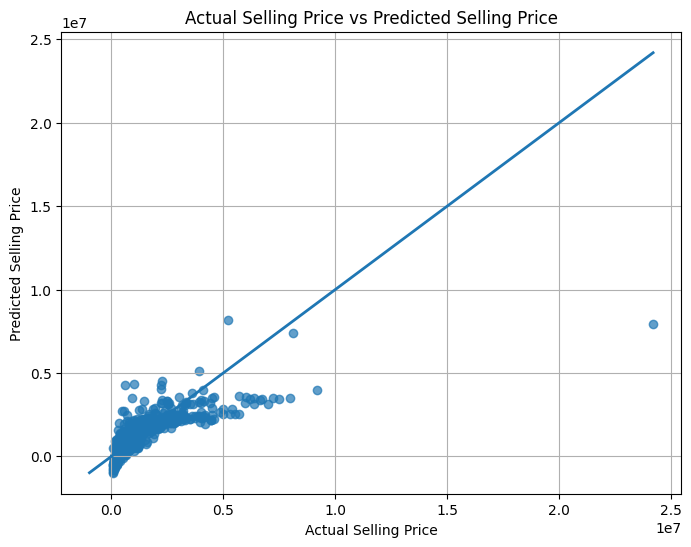

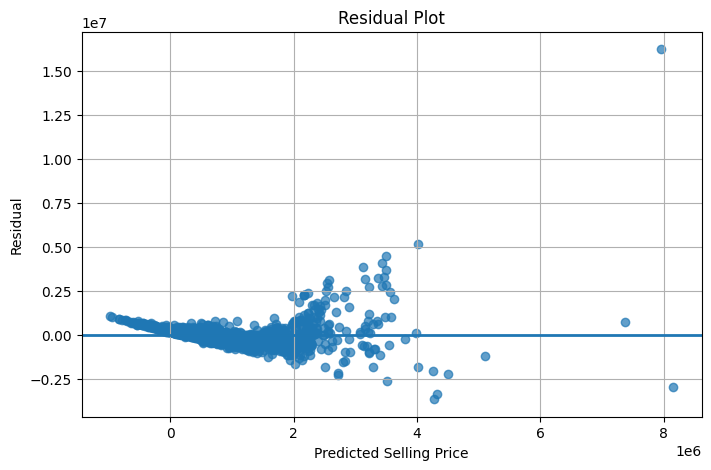

Observations with relatively large prediction errors:


,Actual,Predicted,Residual,Absolute_Error
2796,24200000.0,7.952034e+06,1.624797e+07,1.624797e+07
2362,9200000.0,4.007777e+06,5.192223e+06,5.192223e+06
1382,8000000.0,3.501408e+06,4.498592e+06,4.498592e+06
841,7500000.0,3.429083e+06,4.070917e+06,4.070917e+06
246,7000000.0,3.128805e+06,3.871195e+06,3.871195e+06
1286,7199000.0,3.501408e+06,3.697592e+06,3.697592e+06
26,625000.0,4.271646e+06,-3.646646e+06,3.646646e+06
2528,999000.0,4.323694e+06,-3.324694e+06,3.324694e+06
1493,6750000.0,3.462591e+06,3.287409e+06,3.287409e+06
1092,6645000.0,3.375009e+06,3.269991e+06,3.269991e+06



Explanation of large errors goes here if needed. For now, this is just a placeholder.



In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(
    ytest,
    y_pred,
    alpha=0.7
)
# Perfect prediction line
minimum = min(ytest.min(), y_pred.min())
maximum = max(ytest.max(), y_pred.max())
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linewidth=2
)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual Selling Price vs Predicted Selling Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)
plt.axhline(
    y=0,
    linewidth=2
)
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

error_table = pd.DataFrame({
    "Actual": ytest,
    "Predicted": y_pred,
    "Residual": residuals,
    "Absolute_Error": np.abs(residuals)
})
# Sort by largest absolute error
large_errors = error_table.sort_values(
    by="Absolute_Error",
    ascending=False
)
print("Observations with relatively large prediction errors:")
display(large_errors.head(10))

print("""
Explanation of large errors goes here if needed. For now, this is just a placeholder.
""")

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


In [30]:
# Automatically generate final numerical results
most_influential = importance.iloc[0]

print("=" * 60)
print("EXPERIMENT 3 CONCLUSION")
print("=" * 60)
print(f"\nTraining observations: {len(Xtrain)}")
print(f"Testing observations: {len(Xtest)}")
print(f"\nRSS: {RSS:.4f}")
print(f"R²: {R2:.4f}")
print(f"R² Percentage: {R2 * 100:.2f}%")
print(
    f"\nMost influential feature based on absolute standardized "
    f"coefficient: {most_influential['Feature']}"
)
print(
    f"Coefficient: {most_influential['Coefficient']:.6f}"
)

print("""
\nConclusion:
Multiple Linear Regression was successfully implemented from scratch
using NumPy matrix operations and the Ordinary Least Squares normal
equation.

The model used numerical and encoded categorical features to predict
the selling price of used cars. Feature engineering was performed by
creating Car_Age, and numerical features were standardized using
training-data statistics only.

The model performance was evaluated using RSS and R². A lower RSS
indicates smaller total prediction errors, while a higher R² indicates
that a larger proportion of the variation in selling prices is
explained by the selected predictor variables.

Present price, car age, kilometers driven and categorical attributes
such as fuel type and transmission can influence the predicted selling
price.

Advantages:
1. Simple and easy to understand.
2. Fast to train.
3. Coefficients provide interpretable relationships.
4. Works well when relationships are approximately linear.

Limitations:
1. Assumes a linear relationship between predictors and target.
2. Sensitive to outliers.
3. Multicollinearity can affect coefficients.
4. Used-car prices may have complex non-linear relationships.
5. Important factors not present in the dataset cannot be learned.

Overall, the experiment demonstrates how Multiple Linear Regression
can be implemented without using a ready-made regression function.
""")

EXPERIMENT 3 CONCLUSION

Training observations: 12328
Testing observations: 3083

RSS: 889739123941188.3750
R²: 0.6304
R² Percentage: 63.04%

Most influential feature based on absolute standardized coefficient: max_power
Coefficient: 642366.613872


Conclusion:
Multiple Linear Regression was successfully implemented from scratch
using NumPy matrix operations and the Ordinary Least Squares normal
equation.

The model used numerical and encoded categorical features to predict
the selling price of used cars. Feature engineering was performed by
creating Car_Age, and numerical features were standardized using
training-data statistics only.

The model performance was evaluated using RSS and R². A lower RSS
indicates smaller total prediction errors, while a higher R² indicates
that a larger proportion of the variation in selling prices is
explained by the selected predictor variables.

Present price, car age, kilometers driven and categorical attributes
such as fuel type and transmission can

### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.